In [15]:
import numpy as np

from pybatteryid.utilities import load_model_from_file, invert_voltage_function
from pybatteryid.plotter import plot_time_vs_current

from pybatteryse.statespace import StateSpace
from pybatteryse.filters import ParticleFilter
from pybatteryse.plotter import plot_time_vs_soc
from pybatteryse.utilities import print_statespace_equations

from data import helper

### Load identified model and test dataset

In [16]:
# 
model = load_model_from_file('data/nmc_with_temperature/model_n,l=3,3.npy')
# 
dataset = helper.load_npy_datasets(f'data/nmc_with_temperature/validation_cold.npy')
# 
current_data_with_bad_sensor = np.load(f'data/nmc_with_temperature/validation_cold_automotivecurrent.npy', allow_pickle=True).item()

Here we use bad current sensor values with large bias.

In [17]:
time_values = dataset['time_values'] / 3600
voltage_values = dataset['voltage_values']
temperature_values = dataset['temperature_values']
#
bad_current_values = current_data_with_bad_sensor['current_values']
good_current_values = dataset['current_values']

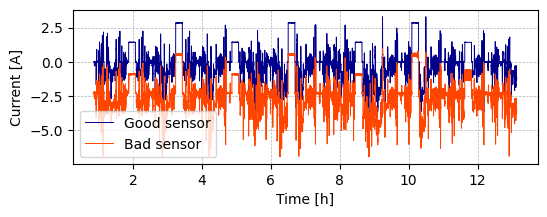

In [18]:
plot_time_vs_current([(time_values, good_current_values), (time_values, bad_current_values[:len(time_values)])],
                      units=('h', 'A'), colors=('darkblue', 'orangered'), legends=['Good sensor', 'Bad sensor'])

### Load state-space representation

In [19]:
ss_representation = StateSpace(model, state_components=['s', 'overpotentials'])

For clarity, we print the employed state-space model structure.

In [20]:
print_statespace_equations(ss_representation)

╭───────────── State-space equations ──────────────╮
│                                                  │
│ x_{k+1} = A(p_k) · x_k + B(p_k) · u_k            │
│ V_k     = EMF(s_k, T_k) + C · x_k + D(p_k) · u_k │
│                                                  │
│ where                                            │
│                                                  │
│ x_k = [s_k, x_1,k, x_2,k, x_3,k]   (dim = 4)     │
│ p_k = [s_k, i_k, T_k]                            │
│ u_k = i_k                                        │
│                                                  │
│          ┌                     ┐                 │
│          │ 1 ¦         0  0  0 │                 │
│          │ --+---------------- │                 │
│ A(p_k) = │ 0 ¦ -a_1(p_k)  1  0 │                 │
│          │ 0 ¦ -a_2(p_k)  0  1 │                 │
│          │ 0 ¦ -a_3(p_k)  0  0 │                 │
│          └                     ┘                 │
│                                                  │
│          ┌                              ┐        │
│          │                       Δt / ℚ │        │
│          │ ---------------------------- │        │
│ B(p_k) = │ b_1(p_k) - a_1(p_k)·b_0(p_k) │        │
│          │ b_2(p_k) - a_2(p_k)·b_0(p_k) │        │
│          │ b_3(p_k) - a_3(p_k)·b_0(p_k) │        │
│          └                              ┘        │
│                                                  │
│     ┌             ┐                              │
│ C = │ 0 ¦ 1  0  0 │                              │
│     └             ┘                              │
│                                                  │
│          ┌          ┐                            │
│ D(p_k) = │ b_0(p_k) │                            │
│          └          ┘                            │
╰──────────────────────────────────────────────────╯

### Load particle filter and run it on the dataset

In [21]:
pf = ParticleFilter(statespace=ss_representation,
                    num_particles=5,
                    eta_bounds=(-4,-1),
                    variance_eta_y_e=1e-3)

# Dataset with bad current values
dataset_for_soc_estimation = {
    'current_values': bad_current_values,
    'voltage_values': voltage_values,
    'temperature_values': temperature_values,
}

state_estimates = pf.run(dataset=dataset_for_soc_estimation,
                         initial_particles='auto')

soc_estimates = state_estimates[:, 0]

PF Progress: 100%|████████████████████████████████████████| 44188/44188 [00:23<00:00, 1869.80step/s]


### Calculate true SOC

We calculate true SOC using coulomb counting with good-quality current measurements

In [22]:
# Coulomb counting method to calculate true SOC
soc_true = np.zeros(len(dataset['time_values']))
# True initial SOC
soc_true[0] = invert_voltage_function(model.emf_function, dataset['voltage_values'][0])

for k in range(1, len(dataset['time_values'])):
    soc_true[k] = soc_true[k - 1] + (dataset['current_values'][k] * model.sampling_period) / model.battery_capacity

### Plot estimated vs true SOC

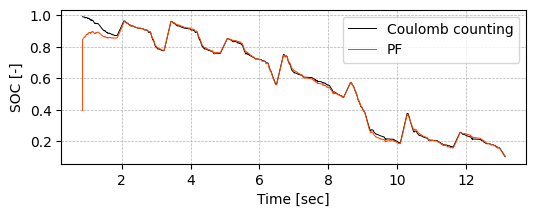

In [23]:
plot_time_vs_soc([(dataset['time_values'] / 3600, soc_true),
                  (dataset['time_values'] / 3600, soc_estimates)],
                  colors=('k', 'orangered'), legends=['Coulomb counting', 'PF'])